# TikTok EDA — Understanding Our Data

Before we can build a recommendation system, we need to actually understand what we're working with. This notebook walks through the data we scraped from TikTok — the videos, comments, and creators — and tries to answer some basic questions:

- What does a typical video look like in our dataset?
- What separates a high-performing video from an average one?
- How do users interact in the comments section?
- Who are the creators posting this content?

We're working with the **silver layer** — data that's already been cleaned, deduplicated, and enriched with derived fields like `engagement_rate`. Each section has a plot followed by an explanation of what it shows and why it matters for building the recommender.

In [1]:
import glob
import os
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SILVER_ROOT = '../extracts/silver'
runs = sorted(
    [r for r in glob.glob(os.path.join(SILVER_ROOT, '*')) if os.path.isdir(r)],
    reverse=True
)
if not runs:
    raise FileNotFoundError(
        f"No silver runs found in '{SILVER_ROOT}'. "
        "Run the EDA pipeline first:\n"
        "  python3 -m eda.pipeline"
    )
latest = runs[0]
print('Using run:', latest)

Using run: ../extracts/silver/20260321_104647


In [2]:
videos   = pd.read_json(os.path.join(latest, 'videos.jsonl'),   lines=True)
comments = pd.read_json(os.path.join(latest, 'comments.jsonl'), lines=True)
authors  = pd.read_csv(os.path.join(latest, 'authors.csv'))

# Cast IDs to string
videos['video_id']     = videos['video_id'].astype(str)
comments['video_id']   = comments['video_id'].astype(str)
comments['comment_id'] = comments['comment_id'].astype(str)
authors['author_id']   = authors['author_id'].astype(str)

print(f'videos:   {len(videos):,} rows')
print(f'comments: {len(comments):,} rows')
print(f'authors:  {len(authors):,} rows')

videos:   1,000 rows
comments: 1,000 rows
authors:  1,000 rows


---
## Part 1 — Videos

These plots answer: *What kind of videos are in our dataset, and which ones perform well?*

### Plot 1 — Engagement Rate Distribution

**Engagement rate** = (likes + comments + shares) / plays

It answers: out of everyone who *watched* the video, what % actually interacted with it? A high engagement rate means the content resonated strongly.

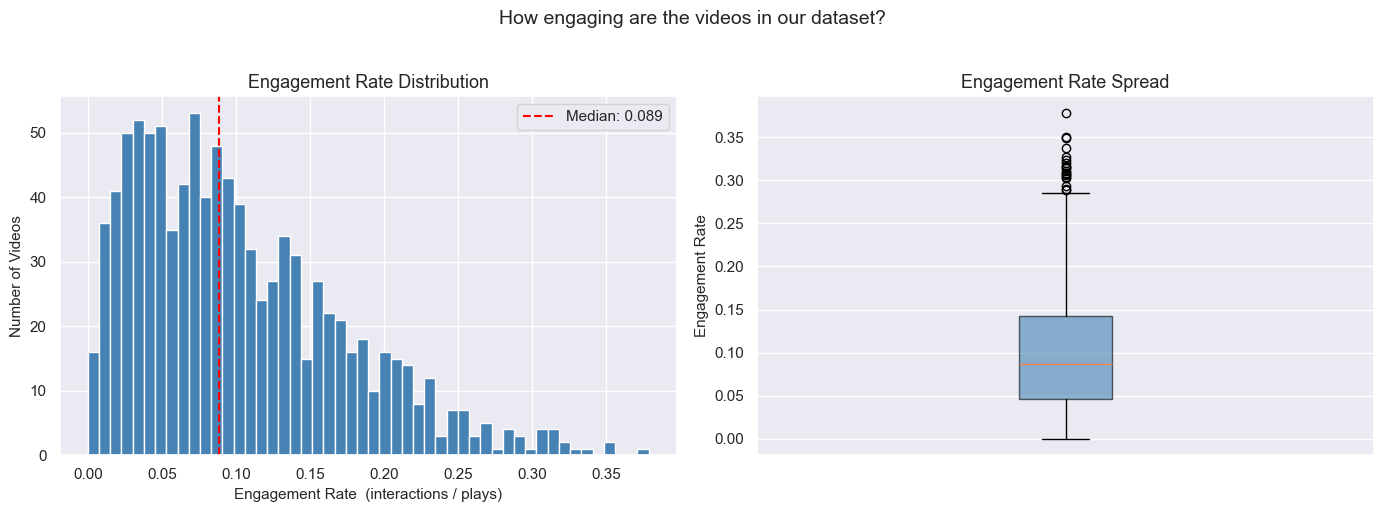

count    997.0000
mean       0.1082
std        0.1050
min        0.0000
25%        0.0463
50%        0.0885
75%        0.1453
max        2.0909
Name: engagement_rate, dtype: float64


In [3]:
er = videos['engagement_rate'].dropna()
er_clipped = er[er < er.quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(er_clipped, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(er.median(), color='red', linestyle='--', label=f'Median: {er.median():.3f}')
axes[0].set_title('Engagement Rate Distribution')
axes[0].set_xlabel('Engagement Rate  (interactions / plays)')
axes[0].set_ylabel('Number of Videos')
axes[0].legend()

axes[1].boxplot(er_clipped, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Engagement Rate Spread')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_xticks([])

plt.suptitle('How engaging are the videos in our dataset?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(er.describe().round(4))

The first thing to notice is how skewed this is — the vast majority of videos cluster near zero, with just a handful reaching really high engagement. That's completely normal for TikTok: most people scroll, watch for a few seconds, and move on without tapping anything. The red line is the median, so half the videos in our dataset sit below that number.

The boxplot on the right makes the outliers obvious — there are videos that are way outside the normal range. For us building a recommender, `engagement_rate` is one of the most important signals we have. We're not trying to just recommend what's popular — we want content that people *actually react to*. A video with 3,000 views and 400 likes is arguably better content than one with 1M views and 2K likes.

### Plot 2 — Likes, Plays, Shares, Comments Distributions

These are the raw interaction counts. We look at all four together to understand what "normal" looks like for each metric.

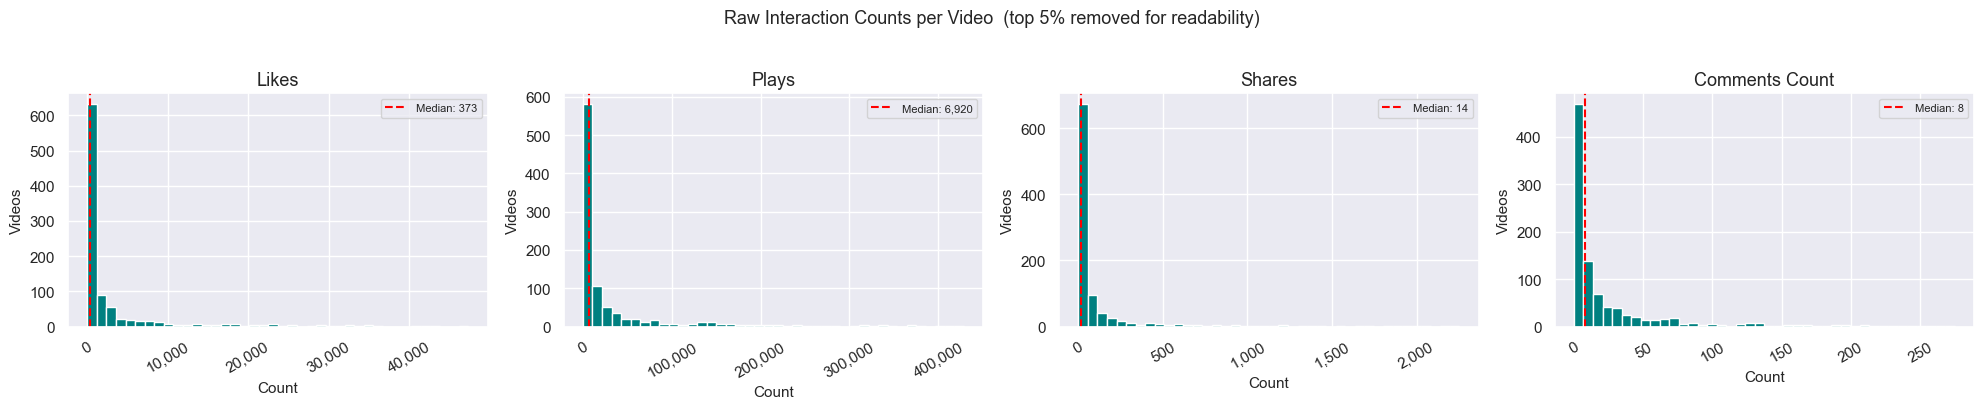

In [4]:
metrics = ['likes', 'plays', 'shares', 'comments_count']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, col in zip(axes, metrics):
    data = videos[col].dropna()
    clipped = data[data < data.quantile(0.95)]
    ax.hist(clipped, bins=40, color='teal', edgecolor='white')
    median_val = data.median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1.5, label=f'Median: {median_val:,.0f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Count')
    ax.set_ylabel('Videos')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.suptitle('Raw Interaction Counts per Video  (top 5% removed for readability)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

All four metrics follow the same shape — long tail, heavily skewed. Most videos get very little, a few explode. What's worth noting is the scale difference between them: plays are always the biggest number by far, because most viewers are completely passive. Shares are the rarest interaction across the board, which actually makes them the strongest signal — if someone goes out of their way to share a video, they genuinely cared about it.

The gap between plays and everything else is exactly what `engagement_rate` captures. It's essentially asking: of all the people who watched this, how many actually did *something*?

### Plot 3 — Top 20 Videos by Engagement Rate

Which specific videos in our dataset performed best? High engagement rate doesn't always mean high views — a small video with lots of interaction is very relevant.

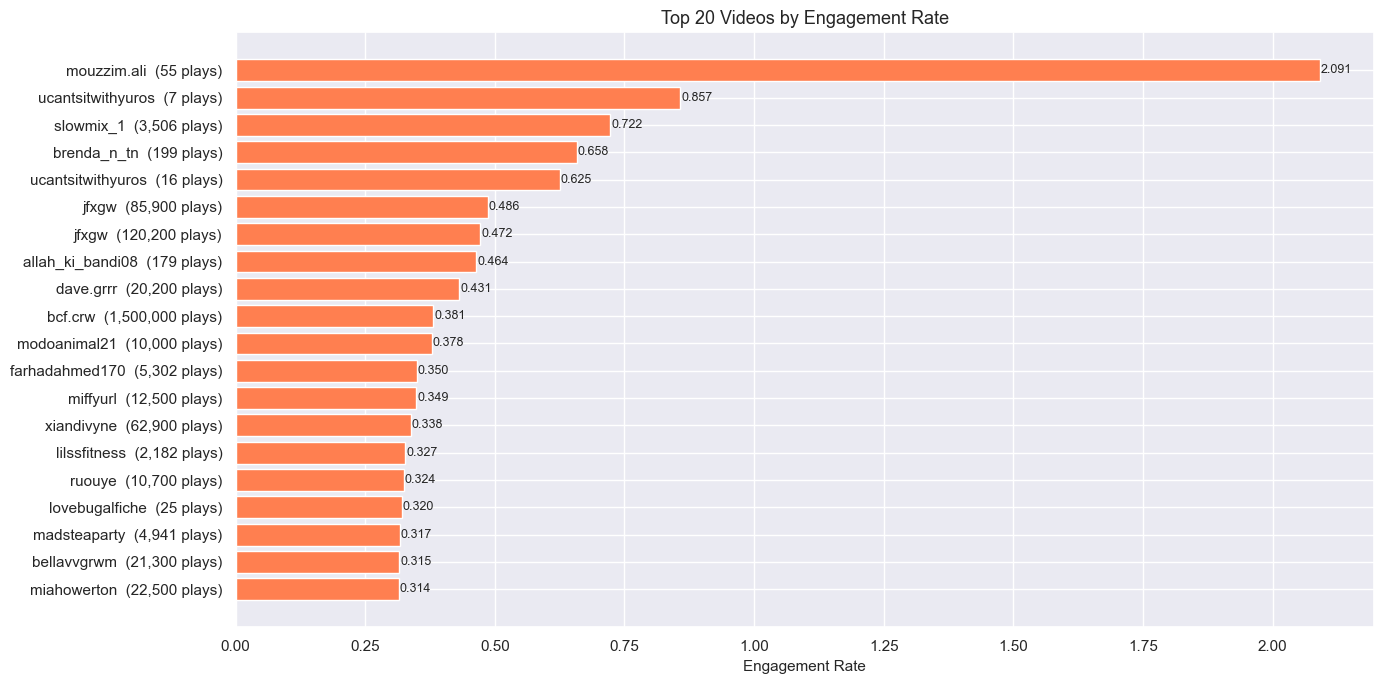

video_author_username  engagement_rate   plays  likes
          mouzzim.ali         2.090909      55     26
    ucantsitwithyuros         0.857143       7      3
            slowmix_1         0.722476    3506   2528
          brenda_n_tn         0.658291     199     60
    ucantsitwithyuros         0.625000      16      5
                jfxgw         0.486275   85900  25000
                jfxgw         0.472155  120200  35000
     allah_ki_bandi08         0.463687     179     78
            dave.grrr         0.430990   20200   7919
              bcf.crw         0.381032 1500000 442800
         modoanimal21         0.378400   10000   2600
       farhadahmed170         0.349679    5302   1728
             miffyurl         0.348800   12500   4203
           xiandivyne         0.337695   62900  18400
         lilssfitness         0.326764    2182    707
               ruouye         0.323925   10700   3413
       lovebugalfiche         0.320000      25      8
         madsteaparty       

In [5]:
top20 = videos.nlargest(20, 'engagement_rate')[
    ['video_id', 'video_author_username', 'engagement_rate', 'plays', 'likes']
].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(
    top20['video_author_username'] + '  (' + top20['plays'].map('{:,}'.format) + ' plays)',
    top20['engagement_rate'], color='coral'
)
ax.set_xlabel('Engagement Rate')
ax.set_title('Top 20 Videos by Engagement Rate')
ax.invert_yaxis()
for bar, val in zip(bars, top20['engagement_rate']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print(top20[['video_author_username', 'engagement_rate', 'plays', 'likes']].to_string(index=False))

These are the 20 videos that resonated the most *proportionally* — the play count in parentheses lets you see both dimensions at once. Some of the highest-engagement videos might have surprisingly low view counts. That's the point: niche content that completely clicks with a small audience scores higher here than something that went semi-viral but didn't really land.

For a recommendation system, these are the kinds of videos we want to surface to the right person. The goal isn't to show everyone the same trending content — it's to find what *this specific user* is likely to react to.

### Plot 4 — Video Duration Distribution

Does video length matter? Short-form content is TikTok's identity, but longer videos are increasingly common. This shows what we actually scraped.

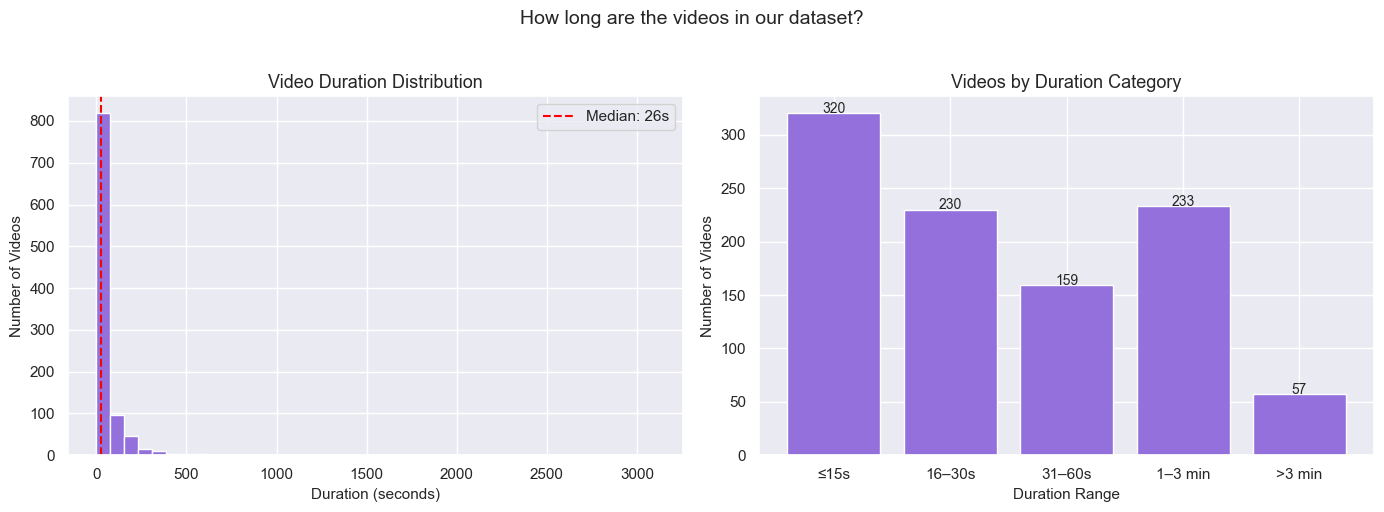

count    1000.0
mean       60.6
std       137.2
min         0.0
25%        15.0
50%        26.0
75%        63.0
max      3101.0
Name: duration_sec, dtype: float64


In [6]:
dur = videos['duration_sec'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dur, bins=40, color='mediumpurple', edgecolor='white')
axes[0].axvline(dur.median(), color='red', linestyle='--', label=f'Median: {dur.median():.0f}s')
axes[0].set_title('Video Duration Distribution')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Number of Videos')
axes[0].legend()

bins   = [0, 15, 30, 60, 180, float('inf')]
labels = ['≤15s', '16–30s', '31–60s', '1–3 min', '>3 min']
dur_cat = pd.cut(dur, bins=bins, labels=labels)
counts  = dur_cat.value_counts().reindex(labels)
axes[1].bar(counts.index, counts.values, color='mediumpurple', edgecolor='white')
axes[1].set_title('Videos by Duration Category')
axes[1].set_xlabel('Duration Range')
axes[1].set_ylabel('Number of Videos')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=10)

plt.suptitle('How long are the videos in our dataset?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(dur.describe().round(1))

TikTok is known for short-form content, but longer videos have become more common — so it's worth seeing what we actually scraped. The right chart breaks it into readable buckets. If most of our data is ≤30s, we're firmly in classic TikTok territory. If there's a wider spread, duration becomes a useful feature to model: some users consistently prefer quick clips, others watch longer content. Either way, this is a user preference we can learn from.

### Plot 5 — Does Duration Affect Engagement?

This scatter plot directly tests whether longer videos get more or less engagement.

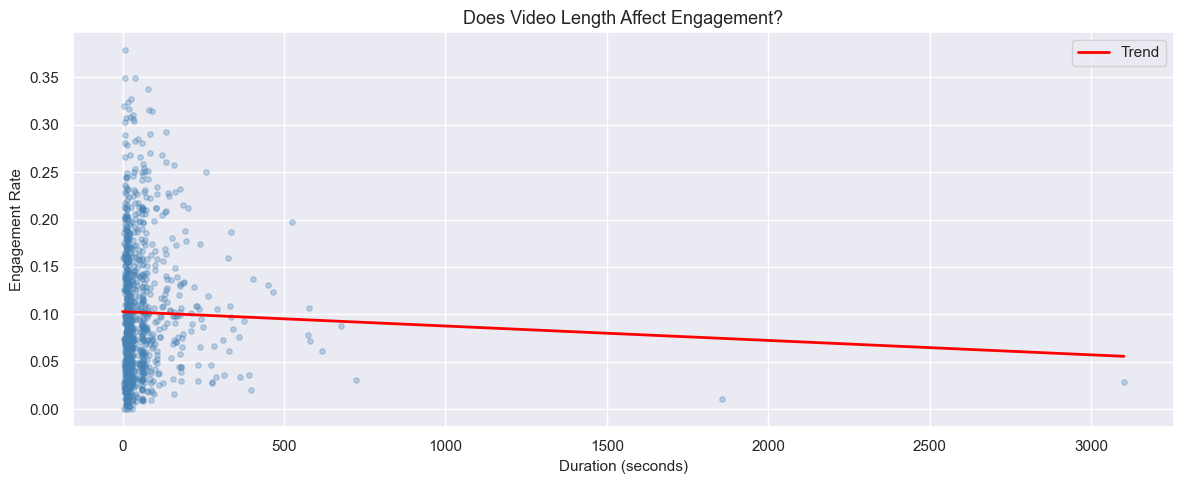

Correlation between duration and engagement rate: -0.030


In [7]:
dur_er = videos[['duration_sec', 'engagement_rate']].dropna()
dur_er = dur_er[dur_er['engagement_rate'] < dur_er['engagement_rate'].quantile(0.99)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(dur_er['duration_sec'], dur_er['engagement_rate'], alpha=0.3, s=15, color='steelblue')

z = np.polyfit(dur_er['duration_sec'], dur_er['engagement_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(dur_er['duration_sec'].min(), dur_er['duration_sec'].max(), 200)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')

ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Engagement Rate')
ax.set_title('Does Video Length Affect Engagement?')
ax.legend()
plt.tight_layout()
plt.show()

corr = dur_er['duration_sec'].corr(dur_er['engagement_rate'])
print(f'Correlation between duration and engagement rate: {corr:.3f}')

Each dot is one video. The red line is the overall trend — if it's flat or slightly downward, that means longer videos don't actually get more engagement. The correlation number printed below confirms this numerically: close to 0 means duration and engagement are basically unrelated, negative means there's a slight penalty for being long.

This is a useful finding because it tells us not to penalize or reward videos based on length. A 3-minute video isn't inherently better or worse than a 15-second one — it depends entirely on the content.

### Plot 6 — Top Hashtags

Hashtags are how TikTok categorizes content. They're crucial for a recommender — they tell us what topics and trends are in our dataset.

In [8]:
all_tags = []
for tags in videos['hashtags'].dropna():
    if isinstance(tags, list):
        all_tags.extend([t.lower().strip('#') for t in tags if t])

if all_tags:
    tag_counts = Counter(all_tags)
    top_tags   = pd.DataFrame(tag_counts.most_common(30), columns=['hashtag', 'count'])

    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.barh(top_tags['hashtag'], top_tags['count'], color='darkcyan')
    ax.set_xlabel('Number of Videos')
    ax.set_title('Top 30 Hashtags in Our Dataset')
    ax.invert_yaxis()
    for bar, val in zip(bars, top_tags['count']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f'Total unique hashtags: {len(tag_counts):,}')
    print(f'Videos with at least one hashtag: {videos["hashtags"].apply(lambda x: isinstance(x, list) and len(x) > 0).sum():,}')
else:
    print('No hashtag data found in this extract.')

No hashtag data found in this extract.


Hashtags are TikTok's main content categorization system, so understanding what's in our dataset is important. The ones dominating the top of this chart are probably generic tags like `#fyp` or `#foryoupage` — those appear on almost every video and don't tell us much about what the content actually is. The more interesting ones are topic-specific tags like `#finance`, `#fitness`, or `#cooking`, because those are what we'd use to match content to user interests.

For a content-based recommender, hashtags are one of the main ways to describe what a video is "about" without watching it.

### Plot 7 — When Are Videos Posted?

This shows what hours of the day our scraped videos were published. Posting time is a weak but real signal.

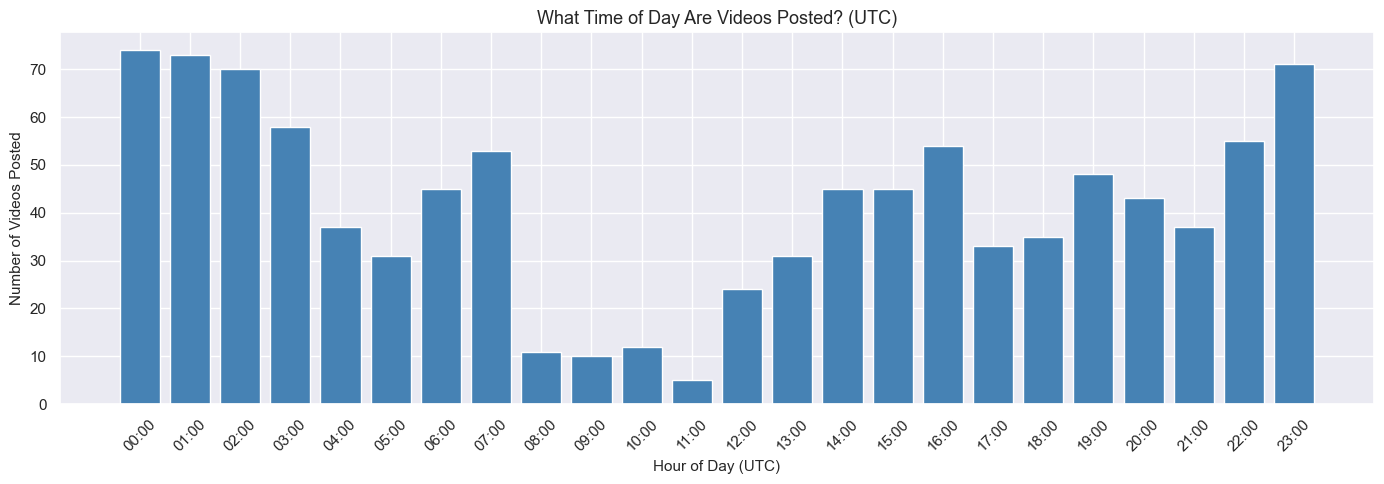

In [9]:
videos['created_at_dt'] = pd.to_datetime(videos['created_at'], utc=True, errors='coerce')
hour_counts = videos['created_at_dt'].dt.hour.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Number of Videos Posted')
ax.set_title('What Time of Day Are Videos Posted? (UTC)')
plt.tight_layout()
plt.show()

This shows what hours of the day our scraped videos were published (UTC). If there's a clear peak, it usually reflects a geographic cluster — creators in the same timezone posting during their local evening when they know their audience is online. It's a weaker signal than engagement rate, but posting time does influence how much early traction a video gets. More users online at the time of posting = more initial exposure, which can snowball into more algorithmic reach.

---
## Part 2 — Comments

These plots answer: *How do users talk about videos? What does text engagement look like?*

### Plot 8 — Comment Length Distribution

Short comments like "😂" or "lol" are very different from long thoughtful ones. Text length is a proxy for how much effort a user put in.

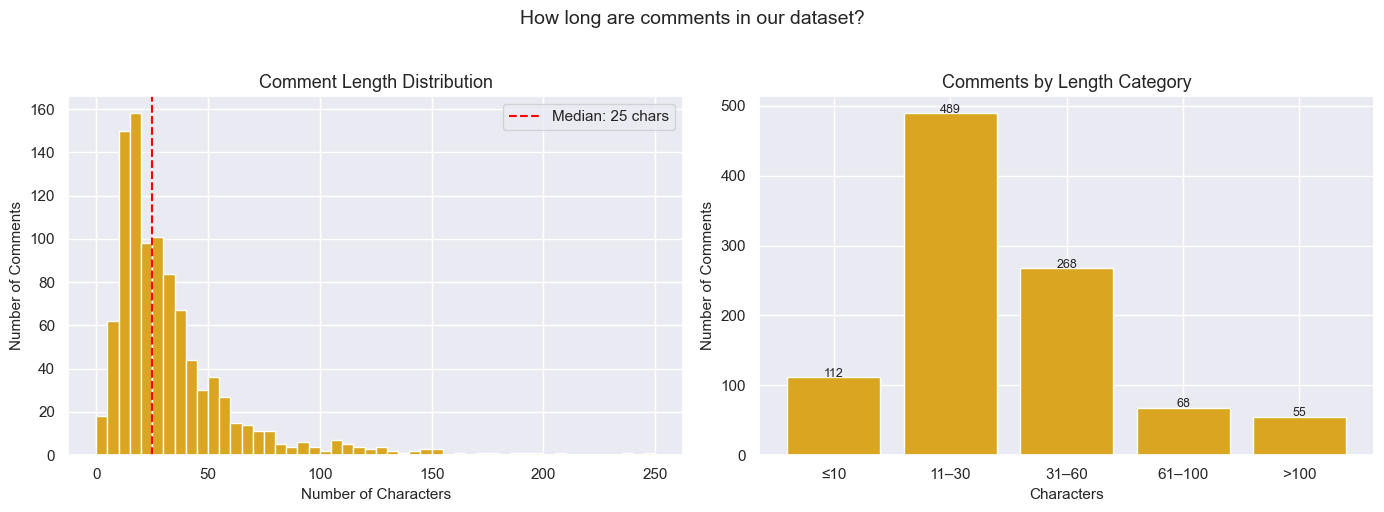

count    1000.0
mean       36.7
std        46.7
min         0.0
25%        15.0
50%        25.0
75%        41.0
max       702.0
Name: text_length, dtype: float64

Example short comments: ['1', 'woo', '🥰🥰🥰', '🥰🥰🥰', 'T']

Example long comments: ['Before you run..you must learn to walk.. before you learn to help others.. first learn to help yourself..', 'The jumbo sizes of Pattern are on sale until 01/24/25 at Ulta so yall better stock up. Cause I did 😭😭']


In [10]:
tl        = comments['text_length'].dropna()
tl_clipped = tl[tl < tl.quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tl_clipped, bins=50, color='goldenrod', edgecolor='white')
axes[0].axvline(tl.median(), color='red', linestyle='--', label=f'Median: {tl.median():.0f} chars')
axes[0].set_title('Comment Length Distribution')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Number of Comments')
axes[0].legend()

buckets       = pd.cut(tl, bins=[0, 10, 30, 60, 100, float('inf')],
                       labels=['≤10', '11–30', '31–60', '61–100', '>100'])
bucket_counts = buckets.value_counts().sort_index()
axes[1].bar(bucket_counts.index, bucket_counts.values, color='goldenrod', edgecolor='white')
axes[1].set_title('Comments by Length Category')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Number of Comments')
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.suptitle('How long are comments in our dataset?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(tl.describe().round(1))

short = comments[comments['text_length'] < 5]['text'].dropna().sample(
    min(5, len(comments[comments['text_length'] < 5])), random_state=42).tolist()
long_ = comments[comments['text_length'] > 100]['text'].dropna().sample(
    min(3, len(comments[comments['text_length'] > 100])), random_state=42).tolist()
print('\nExample short comments:', short)
print('\nExample long comments:', long_[:2])

Short comments dominate — "😂", "lol", "omg", or just a few emojis. The median is probably just a handful of characters. The sample printout at the bottom is useful to sanity-check that the data looks reasonable and we're not missing anything weird in parsing.

For our purposes, very short comments carry almost no semantic signal — there's not much you can do with "🔥🔥" in an NLP model. Longer comments are rarer but more informative. If we ever add a sentiment layer on top of this, comment length would be a useful filter for which comments are worth analyzing.

### Plot 9 — Replies vs Top-level Comments

A reply means a user was engaged enough to respond to someone else. This tells us how much conversation is happening vs simple reactions.

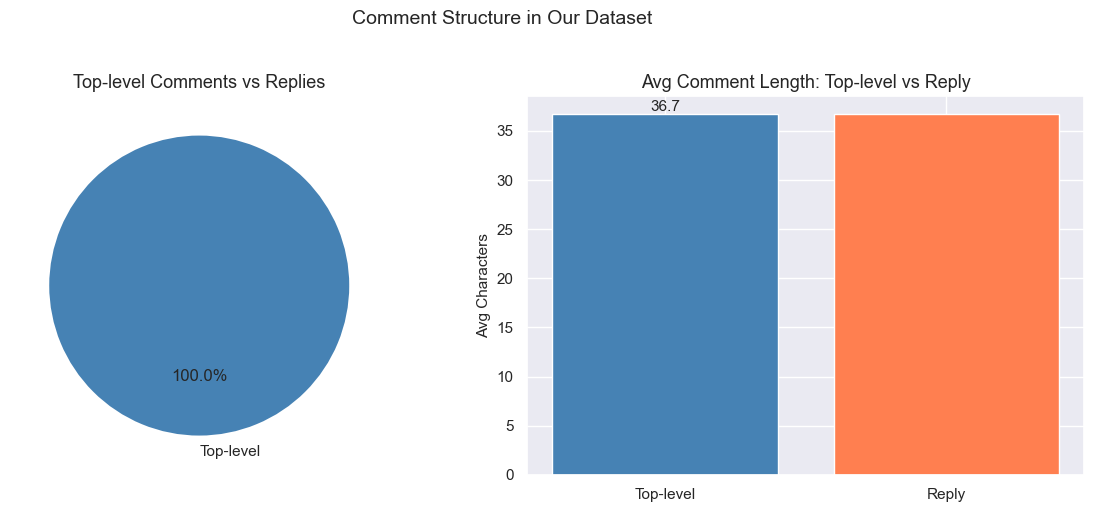

In [11]:
reply_counts = comments['is_reply'].value_counts()
labels       = ['Top-level' if not k else 'Reply' for k in reply_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(reply_counts, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'coral'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Top-level Comments vs Replies')

avg_len = comments.groupby('is_reply')['text_length'].mean()
axes[1].bar(['Top-level', 'Reply'], avg_len.values, color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Avg Comment Length: Top-level vs Reply')
axes[1].set_ylabel('Avg Characters')
for i, v in enumerate(avg_len.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=11)

plt.suptitle('Comment Structure in Our Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

A top-level comment is someone reacting to the video. A reply is someone responding to another comment — meaning the video sparked a real back-and-forth conversation. The right chart is interesting too: if replies tend to be longer than top-level comments, that tells us the conversations are more substantive than the initial reactions.

Videos that generate a lot of replies aren't just getting passive reactions — they're creating community. That's a strong quality signal that goes beyond the basic engagement metrics.

### Plot 10 — Comments per Video

Are comments spread evenly across videos, or concentrated on a few viral ones? This tells us about the shape of user activity.

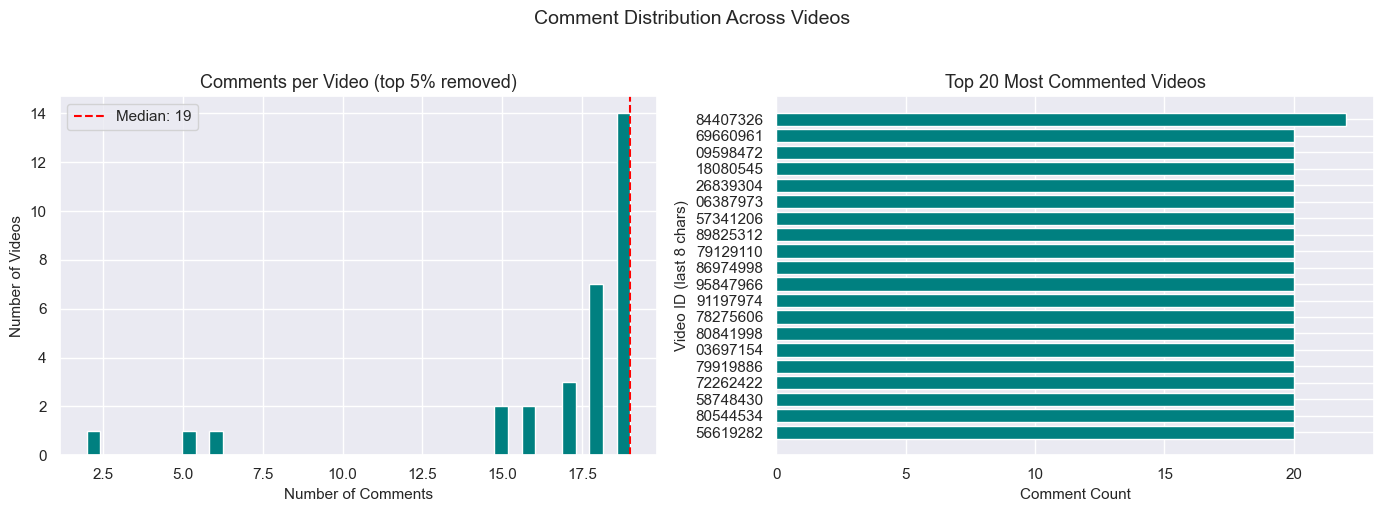

Videos with ≥10 comments:  52
Videos with ≥50 comments:  0
Median comments per video:  19.0


In [12]:
comments_per_video = comments.groupby('video_id').size().reset_index(name='comment_count')
cpv = comments_per_video['comment_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cpv[cpv < cpv.quantile(0.95)], bins=40, color='teal', edgecolor='white')
axes[0].axvline(cpv.median(), color='red', linestyle='--', label=f'Median: {cpv.median():.0f}')
axes[0].set_title('Comments per Video (top 5% removed)')
axes[0].set_xlabel('Number of Comments')
axes[0].set_ylabel('Number of Videos')
axes[0].legend()

top20_commented = comments_per_video.nlargest(20, 'comment_count')
axes[1].barh(top20_commented['video_id'].str[-8:], top20_commented['comment_count'], color='teal')
axes[1].set_title('Top 20 Most Commented Videos')
axes[1].set_xlabel('Comment Count')
axes[1].set_ylabel('Video ID (last 8 chars)')
axes[1].invert_yaxis()

plt.suptitle('Comment Distribution Across Videos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Videos with ≥10 comments:  {(cpv >= 10).sum()}')
print(f'Videos with ≥50 comments:  {(cpv >= 50).sum()}')
print(f'Median comments per video:  {cpv.median():.1f}')

The long-tail problem shows up here clearly — a few videos attract almost all the comments, and most have barely any. This matters for how we design the recommender: if we try to use comment *content* as a signal, we won't have enough text for most videos to work with. Comment *count*, on the other hand, is a clean numeric signal we can use everywhere. The right chart shows which specific videos are driving the most conversation in our dataset.

---
## Part 3 — Authors / Creators

These plots answer: *Who are the creators in our dataset? Are they big influencers or regular users?*

### Plot 11 — Author Videos Count

How many videos has each creator posted? This tells us if we're looking at active creators or one-off posters.

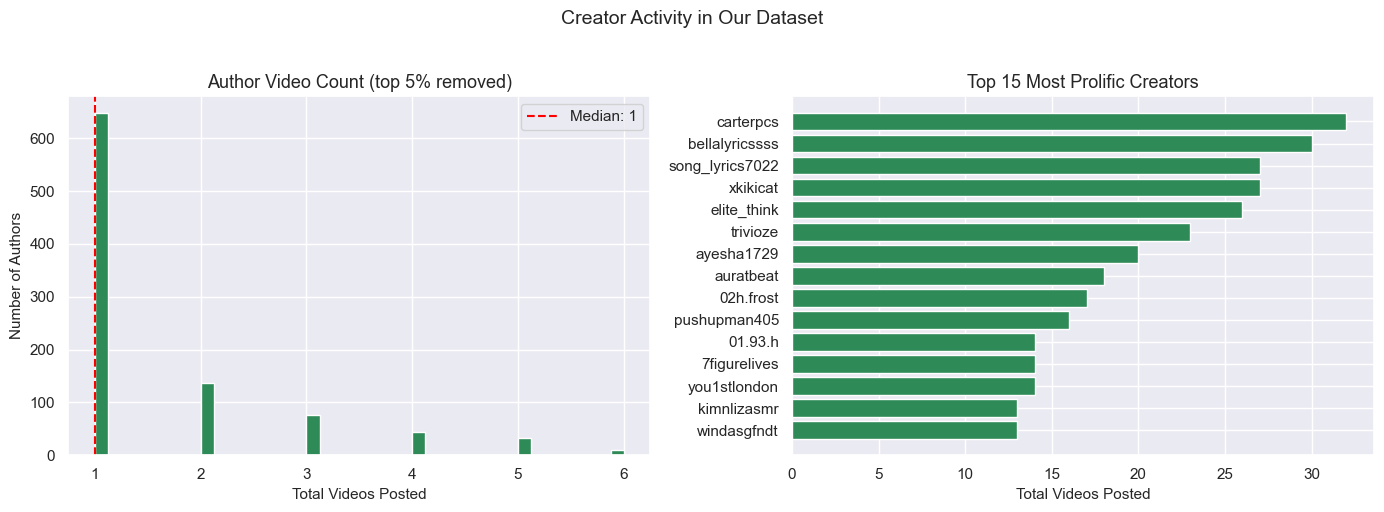

count    1000.0
mean        2.2
std         3.0
min         1.0
25%         1.0
50%         1.0
75%         2.0
max        32.0
Name: videos_count, dtype: float64


In [13]:
vc        = authors['videos_count'].dropna()
vc_clipped = vc[vc < vc.quantile(0.95)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vc_clipped, bins=40, color='seagreen', edgecolor='white')
axes[0].axvline(vc.median(), color='red', linestyle='--', label=f'Median: {vc.median():.0f}')
axes[0].set_title('Author Video Count (top 5% removed)')
axes[0].set_xlabel('Total Videos Posted')
axes[0].set_ylabel('Number of Authors')
axes[0].legend()

top_creators = authors.nlargest(15, 'videos_count')[['username', 'videos_count']].reset_index(drop=True)
axes[1].barh(top_creators['username'].fillna('unknown'), top_creators['videos_count'], color='seagreen')
axes[1].set_title('Top 15 Most Prolific Creators')
axes[1].set_xlabel('Total Videos Posted')
axes[1].invert_yaxis()

plt.suptitle('Creator Activity in Our Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(vc.describe().round(1))

This tells us what kind of creators are in our dataset — are they active, regular posters, or people who uploaded a few videos and went quiet? If most creators have very few videos, it means we don't have much history per creator to work with, which limits how much we can infer about their content style. The right chart names the most prolific creators — these accounts have the most data points and are probably more "professional" content producers rather than casual users.

### Plot 12 — Avg Video Plays per Author

How big is each creator's typical audience? This separates micro-creators from viral ones.

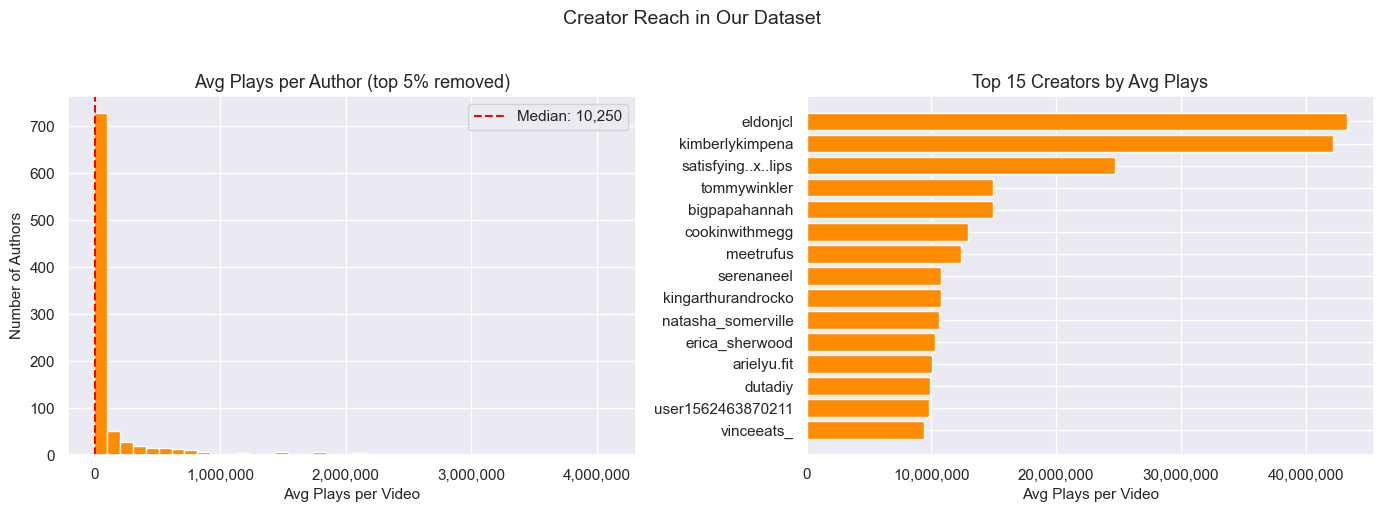

In [14]:
ap        = authors['avg_video_plays'].dropna()
ap_clipped = ap[ap < ap.quantile(0.95)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ap_clipped, bins=40, color='darkorange', edgecolor='white')
axes[0].axvline(ap.median(), color='red', linestyle='--', label=f'Median: {ap.median():,.0f}')
axes[0].set_title('Avg Plays per Author (top 5% removed)')
axes[0].set_xlabel('Avg Plays per Video')
axes[0].set_ylabel('Number of Authors')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend()

top_plays = authors.nlargest(15, 'avg_video_plays')[['username', 'avg_video_plays', 'videos_count']].reset_index(drop=True)
axes[1].barh(top_plays['username'].fillna('unknown'), top_plays['avg_video_plays'], color='darkorange')
axes[1].set_title('Top 15 Creators by Avg Plays')
axes[1].set_xlabel('Avg Plays per Video')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].invert_yaxis()

plt.suptitle('Creator Reach in Our Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Prolific doesn't mean popular. This chart separates the two — a creator with 500 videos averaging 800 plays is a very different case from one with 10 videos averaging 2M plays. The distribution is probably quite skewed, with a handful of high-reach creators dominating.

For a recommender, high-reach creators are useful reference points, but we still need to factor in engagement rate. A creator with millions of average plays but low engagement might just have great distribution, not great content.

---
## Part 4 — Relationships Between Variables

These plots answer: *Which signals actually predict engagement? What correlates with what?*

### Plot 13 — Correlation Heatmap

Shows how much each pair of metrics moves together. Values close to +1 = strong positive link. Close to -1 = opposite. Close to 0 = no relationship.

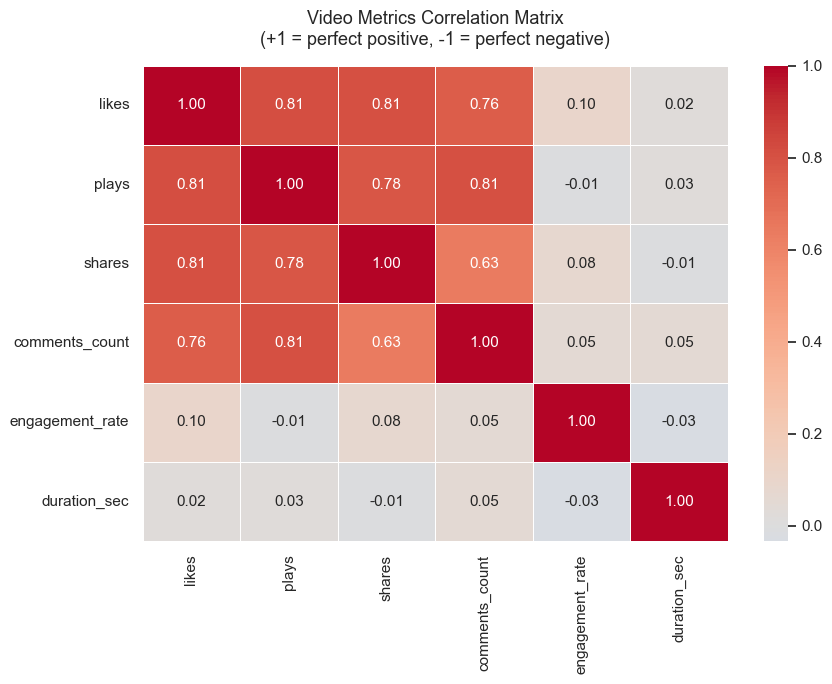

In [15]:
corr_cols = ['likes', 'plays', 'shares', 'comments_count', 'engagement_rate', 'duration_sec']
corr      = videos[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Video Metrics Correlation Matrix\n(+1 = perfect positive, -1 = perfect negative)', pad=15)
plt.tight_layout()
plt.show()

The diagonal is always 1.0 — a metric always correlates with itself, so ignore that. The interesting cells are the off-diagonal ones. `likes` vs `plays` is probably high, which just means popular videos get more of everything — not very surprising. The more important cell is `engagement_rate` vs `plays`: if that's close to 0 or negative, it confirms that raw popularity and content quality are actually separate things. `duration_sec` vs anything tells you whether video length has any real relationship with performance.

A good recommender uses features that don't just track raw popularity — the goal is to surface genuinely good content, including things that haven't gone viral yet.

### Plot 14 — Plays vs Likes (colored by Engagement Rate)

Are high-play videos always high-engagement? Log scale lets us see the full range — from 10 views to millions — without squishing the data.

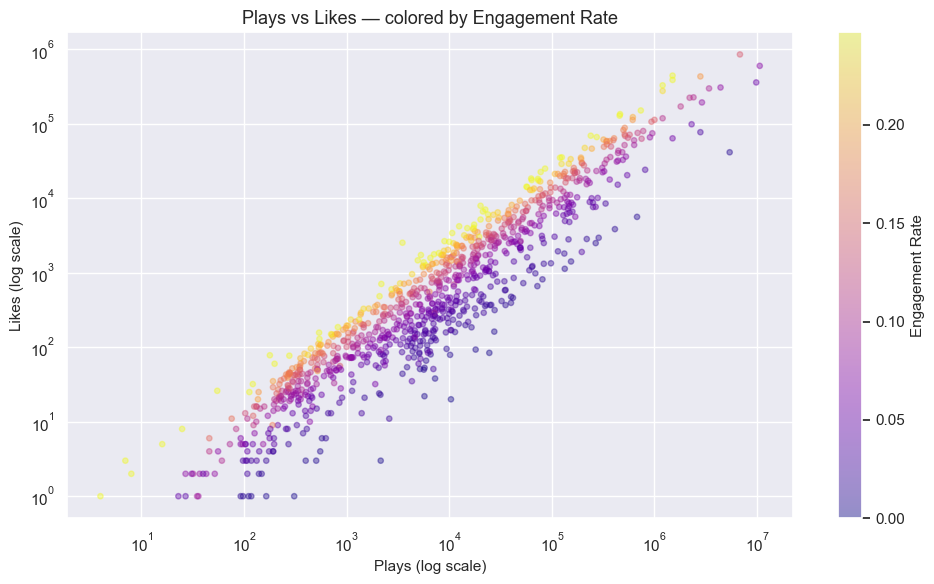

In [16]:
pl = videos[['plays', 'likes', 'engagement_rate']].dropna()
pl = pl[(pl['plays'] > 0) & (pl['likes'] >= 0)]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    pl['plays'], pl['likes'],
    c=pl['engagement_rate'], cmap='plasma',
    alpha=0.4, s=15,
    norm=plt.Normalize(vmin=0, vmax=pl['engagement_rate'].quantile(0.95))
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Engagement Rate')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Plays (log scale)')
ax.set_ylabel('Likes (log scale)')
ax.set_title('Plays vs Likes — colored by Engagement Rate')
plt.tight_layout()
plt.show()

The log scale is important here — without it, a handful of viral videos would compress everything else into a tiny corner and you'd lose the detail. Each dot is one video; the color shows engagement rate (bright yellow/orange = high engagement, dark purple = low).

If the bright dots are scattered all across the chart rather than clustering in the top-right corner, that confirms the key insight: **engagement rate doesn't track with popularity**. Small videos can be just as engaging as big ones. This is the core argument for why our recommender should be built around engagement signals, not just view counts.

---
## Summary — What We Learned

After going through all of this, a few things stand out that should directly shape how we build the recommender:

**Engagement rate ≠ popularity.** A video with few plays but high engagement is genuinely better content. We should use `engagement_rate` as our primary quality signal, not play count — and the scatter plot (Plot 14) makes this visually clear.

**Everything follows a long tail.** Plays, likes, shares, comments — all heavily skewed. A small number of videos and creators dominate most of the activity. Our system needs to handle this without defaulting to just amplifying whatever's already popular.

**Comments are mostly noise at the text level.** Most TikTok comments are a few characters or an emoji. Comment *count* is a reliable numeric feature we can use everywhere; comment *content* is only useful for the small subset of videos with enough long-form text to analyze.

**Duration doesn't predict engagement.** There's no strong relationship between how long a video is and how well it performs. Use duration as a *user preference* feature (some people like short clips, some don't), not as a proxy for quality.

**Hashtags are our best topic signal.** Without topic-specific hashtags, we have limited ways to describe what a video is "about." When they're present, they're one of the most useful inputs for content-based filtering.

The through-line across all of this: build a recommender that balances content quality, topic relevance, and creator identity — not one that just re-surfaces what's already trending.